In [56]:
import pandas as pd

demo_data = pd.read_table("/Users/brainsimulation/Desktop/HCPEP2025-full_HCP/ndar_subject01.txt")
demo_data[demo_data.columns[:15]]

,collection_id,ndar_subject01_id,dataset_id,subjectkey,src_subject_id,interview_date,interview_age,sex,race,ethnic_group,phenotype,phenotype_description,twins_study,sibling_study,family_study
0,collection_id,ndar_subject01_id,dataset_id,The NDAR Global Unique Identifier (GUID) for r...,Subject ID how it's defined in lab/project,Date on which the interview/genetic test/sampl...,Age in months at the time of the interview/tes...,Sex of subject at birth,Race of study subject,Ethnic group,Phenotype/diagnosis for the subject,Description of the phenotype for the subject,Is this study of twins?,Was it sibling study? Study of sibling(s) of a...,Was it family study? Study of biological mothe...
1,2914,852445,39130,NDAR_INVBM164WP7,1001,10/01/2016,362,M,Black or African American,0,Control,In good health,No,No,No
2,2914,852446,39130,NDARHD119LWZ,1002,10/01/2016,243,F,White,0,Control,In good health,No,No,No
3,2914,852447,39130,NDARVU392HH2,1003,10/01/2016,324,F,White,0,Control,In good health,No,No,No
4,2914,852448,39130,NDAR_INVWE537HLY,1004,10/01/2016,296,F,White,0,Control,In good health,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,2914,852692,39130,NDARKA491VAG,4095,02/01/2020,341,F,White,0,Patient,Affective psychosis,No,No,No
249,2914,852693,39130,NDARED446HWN,4096,03/01/2020,264,F,White,0,Patient,Affective psychosis,No,No,No
250,2914,852694,39130,NDARVA329NTW,4097,04/01/2020,322,M,White,0,Patient,Affective psychosis,No,No,No
251,2914,852695,39130,NDARGK424RPR,4098,05/01/2020,348,M,White,0,Patient,Non-affective psychosis,No,No,No


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_72373/2551581185.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ts = np.array(nib.load("/Users/brainsimulation/Desktop/HCPEP2025-full_HCP/derivatives/xcp_d/sub-1012/ses-1/func/sub-1012_ses-1_task-rest_dir-AP_space-fsLR_seg-Glasser_den-91k_stat-mean_timeseries.ptseries.nii").dataobj)


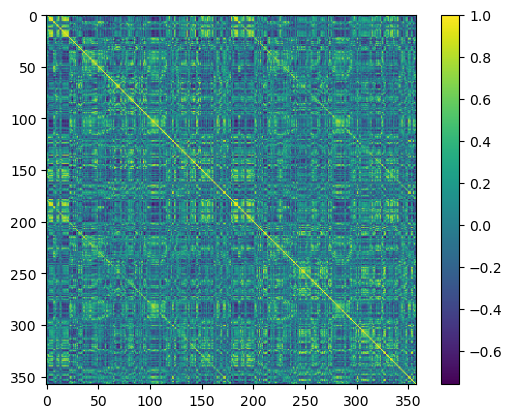

In [41]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

atlas = nib.load("/Users/brainsimulation/Desktop/HCPEP2025-full_HCP/derivatives/xcp_d/atlases/atlas-Glasser/atlas-Glasser_space-fsLR_den-91k_dseg.dlabel.nii")
label_dict = atlas.header.get_axis(0).label[0]

ts = np.array(nib.load("/Users/brainsimulation/Desktop/HCPEP2025-full_HCP/derivatives/xcp_d/sub-1012/ses-1/func/sub-1012_ses-1_task-rest_dir-AP_space-fsLR_seg-Glasser_den-91k_stat-mean_timeseries.ptseries.nii").dataobj)

# for i in range(ts.shape[1]):
#     if np.all(np.isnan(ts[:, i])):
#         print(i)

excluded_regions = ["L_PreS_ROI", "R_PreS_ROI"]

to_delete = []
for i, tuple in label_dict.items():
    if tuple[0] in excluded_regions:
        to_delete.append(i)

ts = np.delete(ts, to_delete, 1)

cutoff = 5
ts = ts[cutoff:]
fc = np.corrcoef(ts, rowvar=False)

plt.imshow(fc)
plt.colorbar()

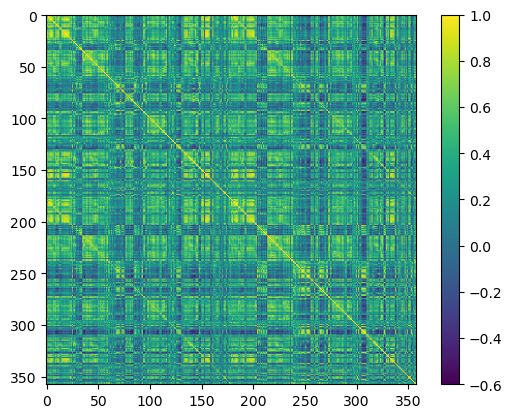

In [62]:
fc = np.loadtxt("out/results/static/sub-1002/sub-1002_FC_mean_raw.csv", delimiter=',')
plt.imshow(fc, vmin=-0.6)
plt.colorbar()

In [145]:
import pickle

atlas = nib.load("/Users/brainsimulation/Desktop/HCPEP2025-full_HCP/derivatives/xcp_d/atlases/atlas-Glasser/atlas-Glasser_space-fsLR_den-91k_dseg.dlabel.nii")
label_dict = atlas.header.get_axis(0).label[0]

labels = [v[0] for k, v in label_dict.items() if k > 0]
with open("resources/labels.pkl", "wb") as f:
    pickle.dump(labels, f)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [142]:
to_delete

[119, 299]

In [174]:
from numpy.linalg import eigh

fc = np.loadtxt("out/results/static/sub-1002/sub-1002_FC_mean_raw.csv", delimiter=',')

# Set negative connectivity to 0
fc[fc < 0] = 0

eigenvalues, eigenvectors = eigh(fc)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# module_map = np.empty_like(fc, dtype=object)
# for i in range(len(module_map[0])):
#     module_map[0, i] = str(0)
module_map = np.zeros_like(fc)
n_levels = 0
for i in range(1, len(fc)):
    eigenmode = eigenvectors[:, i]
    for j in range(len(eigenmode)):
        base = module_map[i-1, j]*2
        if eigenmode[j] > 0:
            module_map[i, j] = base + 0
        else:
            module_map[i, j] = base + 1
    if len(np.unique(module_map[i, :])) == len(fc):
        n_levels = i
        break
module_map = module_map[:n_levels+1, :]

module_map

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [3.0000000e+00, 3.0000000e+00, 2.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.3986473e+07, 1.3619284e+07, 9.5228580e+06, ..., 3.3136650e+06,
        1.0199470e+06, 3.1205480e+06],
       [2.7972946e+07, 2.7238568e+07, 1.9045716e+07, ..., 6.6273300e+06,
        2.0398950e+06, 6.2410970e+06],
       [5.5945892e+07, 5.4477137e+07, 3.8091433e+07, ..., 1.3254660e+07,
        4.0797910e+06, 1.2482194e+07]], shape=(27, 358))

In [181]:
def create_modules(module_map, level):
    modules = []
    for m in np.unique(module_map[level]):
        module = []
        for i in range(len(module_map[level])):
            if module_map[level, i] == m:
                module.append(i)
        modules.append(module)
    return modules

ms = create_modules(module_map, 5)

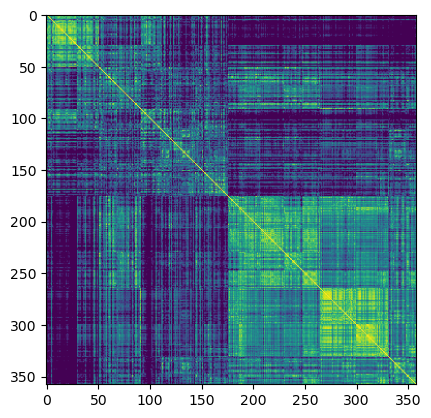

In [182]:
network_ordering = []
for m in ms:
    for i in m:
        network_ordering.append(i)
idx_transform = {}
for net_i, og_i in enumerate(network_ordering):
    idx_transform[og_i] = net_i

new_fc = np.zeros_like(fc)
for i in range(len(fc)):
    for j in range(len(fc)):
        new_i = idx_transform[i]
        new_j = idx_transform[j]
        new_fc[new_i, new_j] = fc[i, j]

plt.imshow(new_fc)

In [ ]:
def H_i(i, module_map):
    modules = create_modules(module_map, i)
    N = module_map.shape[1]
    M_i = len(modules)
    m_j = N/M_i
    p_i = np.sum([np.abs(len(m_j) - N/M_i) for m_j in modules]) / N
    return ( eigenvalues[i]**2 * M_i * (1 - p_i) ) / N

N = module_map.shape[1]
H_In = H_i(0, module_map) / N
H_Se = np.sum([ H_i(i, module_map) for i in range(2, len(module_map)) ]) / N

print(H_In, H_Se)

0.11086608503232102 0.5884195457380275


In [148]:
label_table = pd.read_table("/Users/brainsimulation/Desktop/HCPEP2025-full_HCP/derivatives/xcp_d/atlases/atlas-Glasser/atlas-Glasser_dseg.tsv")
with open("out/intermediaries/to_delete.pkl", "rb") as f:
    to_delete = pickle.load(f)
label_table = label_table.drop(to_delete, axis=0)
label_table

,index,label,cifti_label,community_yeo,community_mesulam,community_economo
0,1,Right_V1,R_V1_ROI,visual,paralimbic,sensory 2
1,2,Right_MST,R_MST_ROI,dorsal attention,unimodal,sensory 1
2,3,Right_V6,R_V6_ROI,visual,unimodal,sensory 1
3,4,Right_V2,R_V2_ROI,visual,paralimbic,sensory 1
4,5,Right_V3,R_V3_ROI,visual,paralimbic,sensory 1
...,...,...,...,...,...,...
355,356,Left_STSva,L_STSva_ROI,default mode,unimodal,association 1
356,357,Left_TE1m,L_TE1m_ROI,default mode,heteromodal,association 1
357,358,Left_PI,L_PI_ROI,ventral attention,idiotypic,association 2
358,359,Left_a32pr,L_a32pr_ROI,frontoparietal,heteromodal,association 1


In [157]:
list(label_table[label_table['community_yeo'] == 'visual'].index)

[0,
 2,
 3,
 4,
 5,
 6,
 12,
 15,
 17,
 18,
 19,
 20,
 21,
 22,
 120,
 126,
 141,
 151,
 152,
 153,
 155,
 157,
 158,
 159,
 162,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 192,
 195,
 197,
 198,
 199,
 200,
 201,
 202,
 298,
 300,
 305,
 306,
 321,
 331,
 332,
 333,
 334,
 335,
 337,
 338,
 339,
 342]

In [208]:
df = pd.read_csv("out/results/graph_theory/global/global_metrics_mean.csv")
df

,subid,patient,abs_mean_connectivity,avg_clustering,global_efficiency,modularity,assortativity,robustness_random,robustness_targeted
0,1012,True,0.206317,0.525205,0.664166,0.121630,0.139354,177.980701,176.872270
1,1001,False,0.207919,0.533783,0.664087,0.136903,0.121610,178.003301,176.812849
2,1009,True,0.237482,0.581692,0.659095,0.132350,0.190392,177.802184,176.497207
3,1002,False,0.319542,0.675898,0.637890,0.132124,0.393859,175.827070,172.114779
4,1066,True,0.237340,0.554614,0.660137,0.146372,0.170453,177.430422,175.755967


In [210]:
df[df["subid"] == "1009"]

,subid,patient,abs_mean_connectivity,avg_clustering,global_efficiency,modularity,assortativity,robustness_random,robustness_targeted
